In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 32

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.25, 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

0it [00:00, ?it/s]

In [3]:
particleState, neighborhood, neighbors, numNeighbors, gt, node_attr, edge_attr, edge_index, adjacency = prepareState(particles, domain, kernel, config)

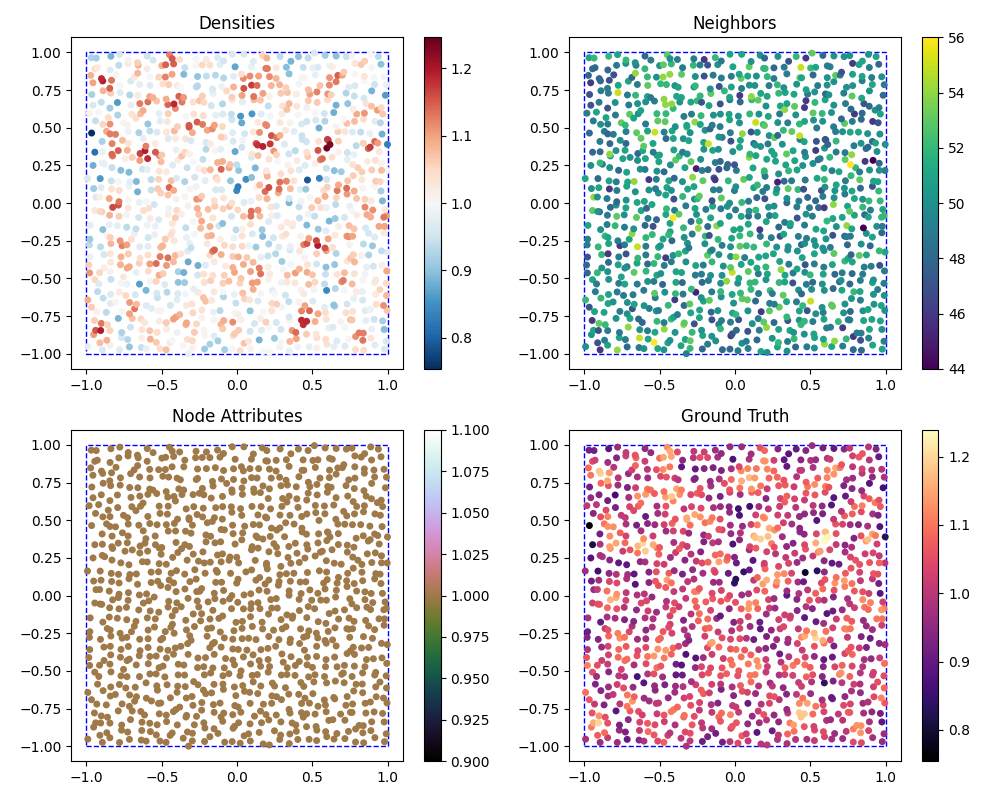

In [4]:
fig, axis = plt.subplots(2,2 , figsize=(10,8), squeeze=False)
markerSize = 16
densityDeviationMax = particleState.densities.max() - 1
densityDeviationMin = particleState.densities.min() - 1
densityRange = max(abs(densityDeviationMax), abs(densityDeviationMin)).cpu().item()

visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.densities,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', markerSize = markerSize, gridVisualization = False, title = 'Densities', vmin = 1-densityRange, vmax = 1+densityRange)

visualizeParticles(fig, axis[0,1], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', markerSize = markerSize, gridVisualization = False, title = 'Neighbors')

visualizeParticles(fig, axis[1,0], particleState, config['domain'], node_attr.view(-1, node_attr.shape[-1]),
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'cubehelix', markerSize = markerSize, gridVisualization = False, title = 'Node Attributes')

visualizeParticles(fig, axis[1,1], particleState, config['domain'], gt.view(-1, gt.shape[-1]),
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Ground Truth')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [5]:
v = particleState.masses / particleState.densities

In [6]:
computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)
from diffSPH.operations import SPHOperation, Operation


neighborhood = neighbors.get('noghost')
shep = SPHOperation(
        particleState,
        quantity = torch.ones_like(v),
        kernel = kernel,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
    )

shep

tensor([0.9969, 1.0427, 1.0723,  ..., 0.9922, 0.9296, 0.9660], device='cuda:0')

In [7]:
from transformer import *
from ml import *

inputFeatures = node_attr.shape[-1]
outputFeatures = gt.shape[-1]
latentSpaceSize = 8
hiddenMLPSize = 128
hiddenMLPLayers = 2

inputEncoderLayers = 0
outputDecoderLayers = 0

transformerFeatures = 9
multiHeads = 2
batch_size = 1
dim = edge_attr.shape[-1]


In [8]:
shepardValues = SPHOperation(
        particleState,
        quantity = torch.ones_like(v),
        kernel = kernel,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Interpolate,
        supportScheme = SupportScheme.Gather,
    )

In [9]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [10]:
from layers.layer_inputEncoder import InputEncodeLayer

inputEncoder = InputEncodeLayer(
    input_dim = inputFeatures,
    output_dim = latentSpaceSize,
    spatial_dim = dim,

    linearEncode = False,
    encoderMLPDict = None,

    absolutePositionBias = True,
    absolutePositionBiasScaledPositions = False,
    absolutePositionBiasMultiplicative = False,

    absolutePositionBiasBaseEncoding = True,
    absolutePositionBiasBaseFunction = 'ffourier',
    absolutePositionBiasBaseTerms = 8,
    absolutePositionBiasBaseMode = 'cat',

    absolutePositionBiasLinear = True,
    absolutePositionBiasMLPDict = None,

    verbose = True).to(device)



inputEncoderNumFeatures = count_parameters(inputEncoder)
print(f'Number of parameters in Input Encoder: {inputEncoderNumFeatures}')


Initializing Input Encode Layer...
	Dimensions: input_dim=1, output_dim=8, spatial_dim=2
	Input feature encoding: linearEncode=False
	Input feature encoding: encoderMLPDict={'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Absolute Position Bias (APB): absolutePositionBias=True
	Absolute Position Bias (APB): absolutePositionBiasScaledPositions=False
	Absolute Position Bias (APB): absolutePositionBiasMultiplicative=False
	Absolute Position Bias (APB): absolutePositionBiasBaseEncoding=True
	Absolute Position Bias (APB): absolutePositionBiasBaseFunction=ffourier
	Absolute Position Bias (APB): absolutePositionBiasBaseTerms=8
	Absolute Position Bias (APB): absolutePositionBiasBaseMode=cat
	Absolute Position Bias (APB): absolutePositionBiasLinear=True
	Absolute Position Bias (APB): absolutePositionBiasMLPDict={'layout': [64, 64], 'activation': 'celu', 'norm'

In [11]:
print(f'Node attr shape: {node_attr.shape}')
inputEncoded = inputEncoder(node_attr, particleState.positions)
print(f'Input Encoded shape: {inputEncoded.shape}')

Node attr shape: torch.Size([1, 1024, 1])
Running Input Encode Layer...
	Input tokens shape: torch.Size([1, 1024, 1])
	Input positions shape: torch.Size([1024, 2])
	Encoding input features...
	Encoded features shape: torch.Size([1, 1024, 8])
	Encoding absolute position bias (APB)...
	Using basis function encoding for APB
	Encoded positions shape (before flattening): torch.Size([1024, 16])
	Encoded positions shape (after flattening): torch.Size([1024, 16])
	Passing encoded positions through APB encoder
	APB shape: torch.Size([1024, 8])
	Using additive APB
	Features shape after adding APB: torch.Size([1, 1024, 8])
Done running Input Encode Layer.
Input Encoded shape: torch.Size([1, 1024, 8])


In [12]:
# project first
inputEncoded # shape is [B, N, L]
edge_attr # shape is [E, dim]
encoded = basisEncoderLayer(
    edge_attr,
    8, 'ffourier', 'cat'
) # shape is [E, B]

W_q = torch.nn.Linear(latentSpaceSize, transformerFeatures * multiHeads, bias=False).to(device)
W_k = torch.nn.Linear(latentSpaceSize, transformerFeatures * multiHeads, bias=False).to(device)

q = W_q(inputEncoded).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, N, H, F]
k = W_k(inputEncoded).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, N, H, F]

print(W_q.weight.shape)

q_i = q[:, edge_index[0], :, :]  # Shape: [B, E, H, F]
k_j = k[:, edge_index[1], :, :]  # Shape: [B, E, H, F]

print(f'Query shape: {q_i.shape}, Key shape: {k_j.shape}, Edge attr shape: {edge_attr.shape}')

attention = (q_i * k_j).sum(dim=-1) / (transformerFeatures ** 0.5)  # Shape: [B, E, H]
print(f'Attention shape: {attention.shape}')

torch.Size([18, 8])
Query shape: torch.Size([1, 51334, 2, 9]), Key shape: torch.Size([1, 51334, 2, 9]), Edge attr shape: torch.Size([51334, 2])
Attention shape: torch.Size([1, 51334, 2])


In [13]:
# scatter first
inputEncoded # shape is [B, N, L]
edge_attr # shape is [E, dim]
encoded = basisEncoderLayer(
    edge_attr,
    8, 'ffourier', 'cat'
) # shape is [E, B]

print(W_q.weight.shape)

node_i = inputEncoded[:, edge_index[0], :]  # Shape: [B, E, L]
node_j = inputEncoded[:, edge_index[1], :]  # Shape: [B, E, L]

Q_i = W_q(node_i).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]
K_j = W_k(node_j).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]

print(f'Query shape: {Q_i.shape}, Key shape: {K_j.shape}, Edge attr shape: {edge_attr.shape}')

attention2 = (Q_i * K_j).sum(dim=-1) / (transformerFeatures ** 0.5)  # Shape: [B, E, H]
print(f'Attention shape: {attention2.shape}')

torch.Size([18, 8])
Query shape: torch.Size([1, 51334, 2, 9]), Key shape: torch.Size([1, 51334, 2, 9]), Edge attr shape: torch.Size([51334, 2])
Attention shape: torch.Size([1, 51334, 2])


In [14]:
Q_i = W_q(node_i)

# Ensure einsum matches the intended linear transformation: output = input @ weight.T
# node_i: [B, E, L], W_q.weight: [F, L] (F = out_features, L = in_features)
# torch.nn.Linear applies: output[b, e, f] = sum_l node_i[b, e, l] * W_q.weight[f, l]
# So einsum should be: 'bel,fl->bef'
Q_i2 = torch.einsum('bel,fl->bef', node_i, W_q.weight)

Q_i, Q_i2

(tensor([[[ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          [ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          [ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          ...,
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537],
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537],
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537]]],
        device='cuda:0', grad_fn=<UnsafeViewBackward0>),
 tensor([[[ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          [ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          [ 0.0641, -0.0234, -0.0621,  ..., -0.0709,  0.1395, -0.0018],
          ...,
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537],
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537],
          [ 0.1321, -0.0410, -0.1253,  ..., -0.0815,  0.1147, -0.0537]]],
        device='cuda:0', grad_fn=<ViewBackwar

In [15]:
# cconv style
inputEncoded # shape is [B, N, L]
edge_attr # shape is [E, dim]
encoded = basisEncoderLayer(
    edge_attr,
    8, 'ffourier', 'cat'
) # shape is [E, B]

# print(W_q.weight.shape)

W_wq = torch.nn.Linear(encoded.shape[-1], inputEncoded.shape[-1] * transformerFeatures * multiHeads, bias=False).to(device)
W_wk = torch.nn.Linear(encoded.shape[-1], inputEncoded.shape[-1] * transformerFeatures * multiHeads, bias=False).to(device)

print(W_wq.weight.shape)

w_q = W_wq(encoded)#.view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]
w_k = W_wk(encoded)#.view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]

# print(W_q.weight.shape)
# print(w_q.shape)

node_i = inputEncoded[:, edge_index[0], :]  # Shape: [B, E, L]
node_j = inputEncoded[:, edge_index[1], :]  # Shape: [B, E, L]

Q_i = torch.einsum('bel, fl -> bef', node_i, W_q.weight).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]
K_j = torch.einsum('bel, fl -> bef', node_j, W_k.weight).view(batch_size, -1, multiHeads, transformerFeatures)  # Shape: [B, E, H, F]

print(f'Query shape: {Q_i.shape}, Key shape: {K_j.shape}, Edge attr shape: {edge_attr.shape}')

attention2 = (Q_i * K_j).sum(dim=-1) / (transformerFeatures ** 0.5)  # Shape: [B, E, H]
print(f'Attention shape: {attention2.shape}')

torch.Size([144, 16])
Query shape: torch.Size([1, 51334, 2, 9]), Key shape: torch.Size([1, 51334, 2, 9]), Edge attr shape: torch.Size([51334, 2])
Attention shape: torch.Size([1, 51334, 2])


In [20]:
from layers.layer_attentionMechanism import AttentionMechanismLayer

attentionMechanism = AttentionMechanismLayer(
                    latent_dim = latentSpaceSize,
                    transformer_features= transformerFeatures,
                    edge_dim = edge_attr.shape[-1],
                    num_heads = multiHeads,

                    attentionMechanism = 'dot',
                    attentionScoreMLPDict = None,
                    attentionDropout = 0.0,
                    attentionScaling = True,
                    attentionActivation = 'leaky_relu(0.2)',

                    encodeTokens = True,
                    encodeTokensLinear = True,
                    encodeTokensMLPDict = None,
                    encodeTokensShared = False,
                    cConvMode = False,

                    relativePositionBias = False,
                    relativePositionBiasAfterAttention= False,
                    relativePositionBiasScaledPositions = False,
                    relativePositionBiasMultiplicative = False,
                    relativePositionBiasBaseEncoding = True,
                    relativePositionBiasBaseFunction = 'ffourier',
                    relativePositionBiasBaseTerms = 8,
                    relativePositionBiasBaseMode = 'cat',
                    relativePositionBiasEncoder = False,
                    relativePositionBiasLinear = True,
                    relativePositionBiasMLPDict = None,

                    windowFunction = False,
                    windowFunctionType = 'cubicSpline',
                    windowFunctionBeforeSoftmax = True,

                    skipSoftmax = False,

                    verbose = True).to(device)

attentionMechanismNumFeatures = count_parameters(attentionMechanism)
print(f'Number of parameters in Attention Mechanism: {attentionMechanismNumFeatures}')

Initializing Attention Mechanism Layer with parameters:
	Latent dimension: 8
	Edge dimension: 2
	Transformer dimension: 9
	Number of heads: 2
	Attention Mechanism: dot
	Attention Score MLP Dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Attention Dropout: 0.0
	Attention Scaling: True
	Attention Clipping: False
	Attention Activation: leaky_relu with arguments (0.2,)
	Skip Softmax: False
	Encode Tokens: True
	Encode Tokens Linear: True
	Encode Tokens MLP Dict: {'layout': [64, 64], 'activation': 'celu', 'norm': False, 'bias': False, 'gain': np.float64(0.17149858514250882), 'noLinear': False, 'preNorm': False, 'postNorm': False, 'channels': 1}
	Encode Tokens Shared: False
	Using continuous Convolution Mode: False
	Relative Position Bias: False
	Window Function: False
Building Query/Key Encoding...
	Using separate encoding for query and key
		Using 

In [21]:
attentionValues = attentionMechanism(
    queryTokens = inputEncoded,
    keyTokens = inputEncoded,
    edge_index = edge_index,
    edge_attr = edge_attr,
    edge_scaling = torch.linalg.norm(edge_attr * particleState.supports[edge_index[0]].view(-1,1), dim = -1),
    s_k = None)

print(f'Attention Values shape: {attentionValues.shape}')

#                     Running Attention Mechanism Layer...                     #
	Query tokens shape: torch.Size([1, 1024, 8]) [B, Q, L]
	Key tokens shape: torch.Size([1, 1024, 8]) [B, K, L]
	Edge index shape: torch.Size([2, 51334]) [2, E]
	Edge attr shape: torch.Size([51334, 2]) [E, D]
	Edge scaling shape: torch.Size([51334]) [E]
	S_k shape: None [B,K]
	Input Shapes: [B, Q, K, L, D, E] = [1, 1024, 1024, 8, 2, 51334]
	Transformer Shapes: [H, T, T*H] = [2, 9, 18]
#             Encoding Edge Attributes for Relative Position Bias              #
#                      	Encoding Query and Key Tokens...                       #
Input Token Shape [current ]: torch.Size([1, 1024, 8]) [B 1 x N 1024 x D 8]
Input Token Shape [neighbor]: torch.Size([1, 1024, 8]) [B 1 x N 1024 x D 8]
Query Shape: torch.Size([1, 2, 1024, 9]) [B 1 x H 2 x N 1024 x D 9]
Key Shape:   torch.Size([1, 2, 1024, 9]) [B 1 x H 2 x N 1024 x D 9]
	Scaled Query Shape Tokens by 1/9 ** 0.5
Unified Query Shape: torch.Size([2, 1024, 

In [22]:
attentionValuesH0 = attentionValues[0,0,:]
print(f'Attention Values Head 0 shape: {attentionValuesH0.shape}')

attentionForNode0 = attentionValuesH0[edge_index[0] == 93]
print(f'Attention Values for Node 0 shape: {attentionForNode0.shape}')
print(attentionForNode0)
print(f'Total attention for Node 0: {attentionForNode0.sum()}')

Attention Values Head 0 shape: torch.Size([51334])
Attention Values for Node 0 shape: torch.Size([47])
tensor([0.0210, 0.0210, 0.0210, 0.0210, 0.0211, 0.0211, 0.0212, 0.0212, 0.0212,
        0.0213, 0.0214, 0.0213, 0.0214, 0.0214, 0.0213, 0.0211, 0.0211, 0.0212,
        0.0212, 0.0212, 0.0212, 0.0213, 0.0213, 0.0213, 0.0213, 0.0214, 0.0215,
        0.0213, 0.0214, 0.0215, 0.0215, 0.0213, 0.0213, 0.0214, 0.0214, 0.0213,
        0.0213, 0.0212, 0.0213, 0.0213, 0.0215, 0.0215, 0.0212, 0.0213, 0.0214,
        0.0214, 0.0212], device='cuda:0', grad_fn=<IndexBackward0>)
Total attention for Node 0: 1.0


In [38]:
inputEncoder = buildMLPwDict({
 'inputFeatures': inputFeatures,
 'output' : latentSpaceSize,
 'activation': 'celu',
 'layout': [hiddenMLPSize] * inputEncoderLayers,
 'norm': False,
 'bias': False,
}
).to(device)
transformerLayer = TransformerLayer(
    latentSpaceSize, transformerFeatures, dim, multiHeads,
    edge_bias = False, edge_gating = False, verbose = False, attentionOp = 'dot', attentionOpIncludeEdge = False, sharedWeights=False, headAggregation='concat', v2 = False, messagePassingGAT=False, ffnHiddenLayers=1, ffnHiddenSize=128, edgeBasisEncoder = False, edgeBasisTerms = 8, edgeBasisMode = 'cat',shepardAttention = True).to(device)
outputDecoder = buildMLPwDict({
    'inputFeatures': latentSpaceSize,
    'output' : outputFeatures,
    'activation': 'celu',
    'layout': [hiddenMLPSize] * outputDecoderLayers,
    'norm': False,
    'bias': False
}
).to(device)

numberOfParametersInputEncoder = sum(p.numel() for p in inputEncoder.parameters())
numberOfParametersTransformerLayer = sum(p.numel() for p in transformerLayer.parameters())
numberOfParametersOutputDecoder = sum(p.numel() for p in outputDecoder.parameters())
print(f'Number of parameters in input encoder: {numberOfParametersInputEncoder}')
print(f'Number of parameters in transformer layer: {numberOfParametersTransformerLayer}')
print(f'Number of parameters in output decoder: {numberOfParametersOutputDecoder}')


optimizer = torch.optim.AdamW(list(inputEncoder.parameters()) + list(transformerLayer.parameters()) + list(outputDecoder.parameters()), lr= 1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

Number of parameters in input encoder: 1
Number of parameters in transformer layer: 393
Number of parameters in output decoder: 1


In [ ]:
def modelStep(node_attr, edge_attr, edge_index, inputEncoder, transformerLayer, outputDecoder, shepardValues = None, verbose = False):
    return transformerLayer(node_attr, edge_attr, edge_index, shepardValues=shepardValues)

    encodedInput = inputEncoder(node_attr)
    if verbose:
        print(f'Encoded input shape: {encodedInput.shape} [B {batch_size} x N {node_attr.shape[0]} x L {latentSpaceSize}]')
        print(f'Min: {encodedInput.min().item()}, Max: {encodedInput.max().item()}, Mean: {encodedInput.mean().item()}, Std: {encodedInput.std().item()}')

    transformerOutput = transformerLayer(encodedInput, edge_attr, edge_index)

    if verbose:
        print(f'Output shape: {transformerOutput.shape} [B {batch_size} x N {node_attr.shape[0]} x L {latentSpaceSize}]')
        print(f'Min: {transformerOutput.min().item()}, Max: {transformerOutput.max().item()}, Mean: {transformerOutput.mean().item()}, Std: {transformerOutput.std().item()}')
        print(transformerOutput)
    output = outputDecoder(transformerOutput)
    if verbose:
        print(f'Final output shape: {output.shape} [B {batch_size} x N {node_attr.shape[0]} x L {outputFeatures}]')
        print(f'Min: {output.min().item()}, Max: {output.max().item()}, Mean: {output.mean().item()}, Std: {output.std().item()}')

    return output

modelStep(node_attr, edge_attr, edge_index, inputEncoder, transformerLayer, outputDecoder, shepardValues=shepardValues, verbose = True)


tensor([[[0.0554],
         [0.0539],
         [0.0544],
         ...,
         [0.0551],
         [0.0540],
         [0.0547]]], device='cuda:0', grad_fn=<UnsafeViewBackward0>)

In [45]:
losses = []
lrs = []

predictions = []
for epoch in (tq := tqdm(range(2**16), desc='Training', leave=False)):

    optimizer.zero_grad()
    output = modelStep(node_attr, edge_attr, edge_index, inputEncoder, transformerLayer, outputDecoder, shepardValues=1/shepardValues)
    # print(f'Output shape: {output.shape}, GT shape: {gt.shape}')
    # print(f'Output: {output.min().item():.4f} - {output.max().item():.4f}, GT: {gt.min().item():.4f} - {gt.max().item():.4f}')
    loss = ((output - gt)**2).mean()
    # print(loss.shape)
    # break
    loss.backward()
    optimizer.step()
    scheduler.step()

    losses.append(loss.item())
    lrs.append(scheduler.get_last_lr()[0])

    minPrediction = output.min().detach().cpu().item()
    maxPrediction = output.max().detach().cpu().item()
    meanPrediction = output.mean().detach().cpu().item()
    stdPrediction = output.std().detach().cpu().item()
    predictions.append((minPrediction, maxPrediction, meanPrediction, stdPrediction))
    tq.set_description(f'Training (loss: {loss.item():.4f}, lr: {scheduler.get_last_lr()[0]:.6f}, min: {minPrediction:.4f}, max: {maxPrediction:.4f}, mean: {meanPrediction:.4f}, std: {stdPrediction:.4f})')


    # break


Training:   0%|          | 0/65536 [00:00<?, ?it/s]

KeyboardInterrupt: 

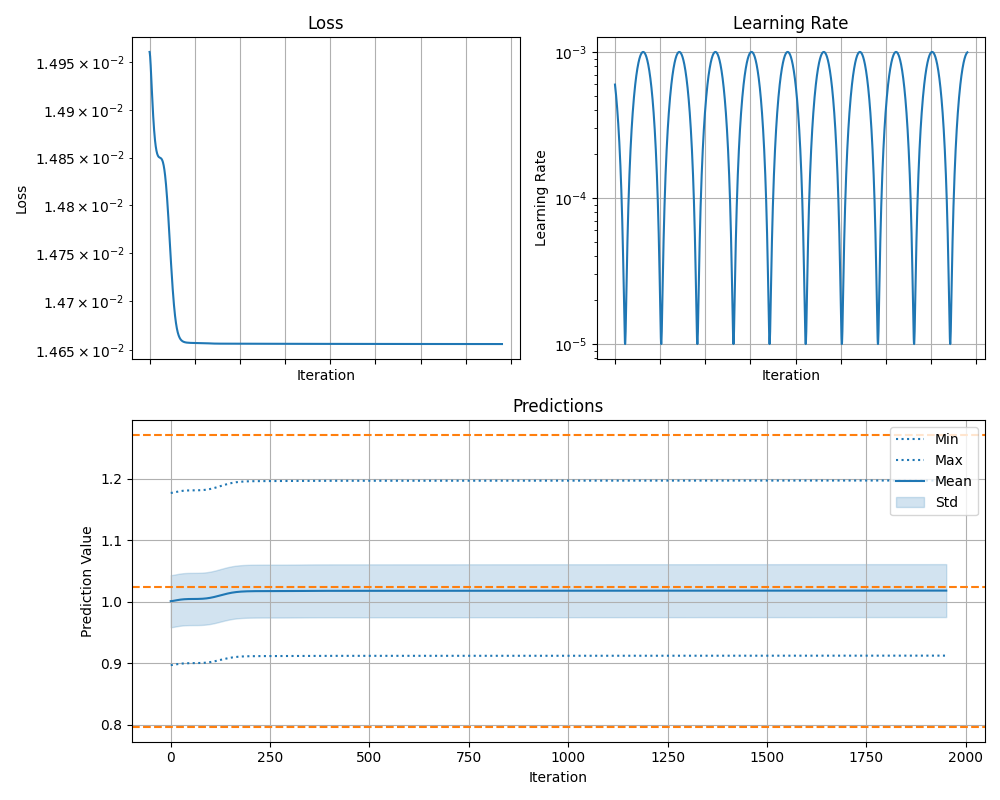

In [46]:
fig, axis = plt.subplot_mosaic('''AB
                               CC''' , figsize=(10,8), sharex=True, sharey=False)
axis['A'].plot(losses)
axis['A'].set_title('Loss')
axis['A'].set_xlabel('Iteration')
axis['A'].set_ylabel('Loss')
axis['A'].set_yscale('log')
axis['A'].grid(True)

axis['B'].plot(lrs)
axis['B'].set_title('Learning Rate')
axis['B'].set_xlabel('Iteration')
axis['B'].set_ylabel('Learning Rate')
axis['B'].set_yscale('log')
axis['B'].grid(True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

axis['C'].plot([p[0] for p in predictions], label='Min', color=colors[0], linestyle=':')
axis['C'].plot([p[1] for p in predictions], label='Max', color=colors[0], linestyle=':')
axis['C'].plot([p[2] for p in predictions], label='Mean', color=colors[0], linestyle='-')
axis['C'].fill_between(range(len(predictions)), [p[2] + p[3] for p in predictions], [p[2] - p[3] for p in predictions], label='Std', color=colors[0], alpha=0.2)
axis['C'].set_title('Predictions')
axis['C'].set_xlabel('Iteration')
axis['C'].set_ylabel('Prediction Value')
axis['C'].set_yscale('linear')
axis['C'].grid(True)
axis['C'].legend()

axis['C'].axhline(gt.min().item(), color=colors[1], linestyle='--')
axis['C'].axhline(gt.max().item(), color=colors[1], linestyle='--')
axis['C'].axhline(gt.mean().item(), color=colors[1], linestyle='--', label='GT')

fig.tight_layout()

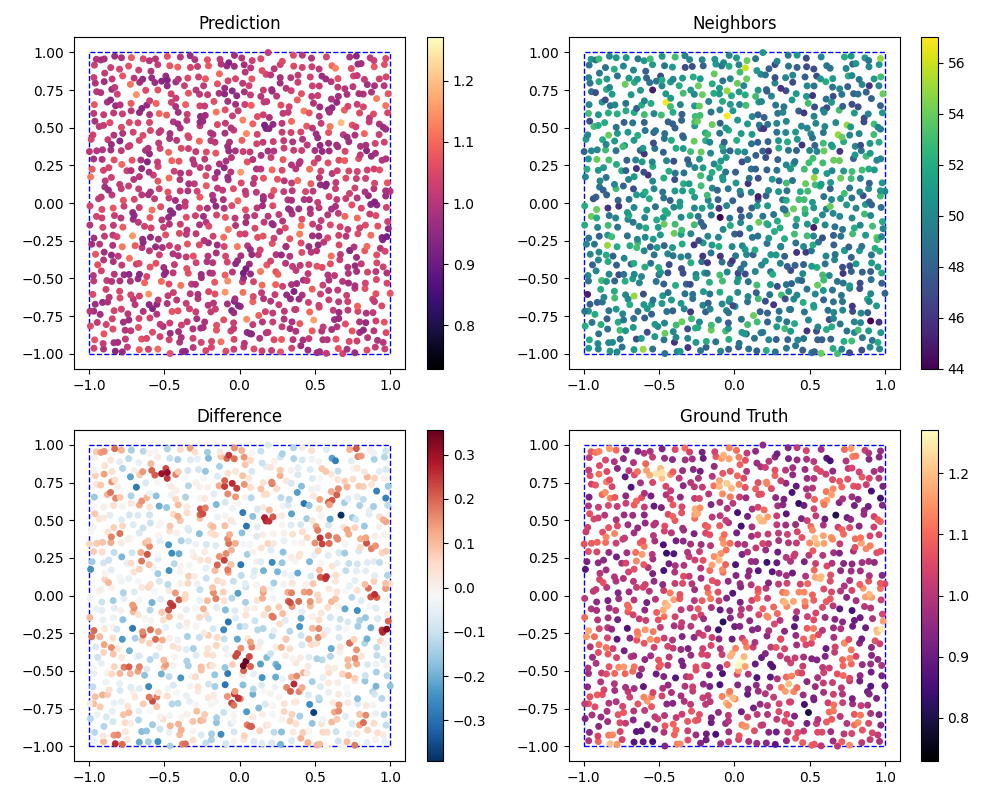

In [47]:
fig, axis = plt.subplots(2,2 , figsize=(10,8), squeeze=False)
markerSize = 16
densityDeviationMax = particleState.densities.max() - 1
densityDeviationMin = particleState.densities.min() - 1
densityRange = max(abs(densityDeviationMax), abs(densityDeviationMin)).cpu().item()

visualizeParticles(fig, axis[0,0], particleState, config['domain'], output.view(-1, output.shape[-1]),
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Prediction', vmin = 1-densityRange, vmax = 1+densityRange)

visualizeParticles(fig, axis[0,1], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', markerSize = markerSize, gridVisualization = False, title = 'Neighbors')

visualizeParticles(fig, axis[1,0], particleState, config['domain'], gt.view(-1, gt.shape[-1]) - output.view(-1, output.shape[-1]),
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', markerSize = markerSize, gridVisualization = False, title = 'Difference')

visualizeParticles(fig, axis[1,1], particleState, config['domain'], gt.view(-1, gt.shape[-1]),
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Ground Truth', vmin = 1-densityRange, vmax = 1+densityRange)

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [ ]:
encodedInput = inputEncoder(node_attr)
transformerOutput = denseNodeTransformer(encodedInput, edge_attr, edge_index)


In [ ]:
h_i = particleState.supports[adjacency.row].to(device)
rij, xij_ = computeSparseDistanceTensor(adjacency)

edge_attr = xij_ / h_i[:,None]
edge_index = torch.stack([adjacency.row, adjacency.col])
print('edge_attr shape:', edge_attr.shape)
print('edge_index shape:', edge_index.shape)


node_attr = (encodedInput.reshape(1, -1, latentSpaceSize), encodedInput.reshape(1, -1, latentSpaceSize))  # Reshape to [B, N, F] for batch processing
print('node_attr shape:', node_attr[0].shape, node_attr[1].shape)
node_attr = encodedInput.reshape(1, -1, latentSpaceSize)



bs = 4
node_attr_batched = (encodedInput.repeat(bs, 1, 1), encodedInput.repeat(bs, 1, 1))  # Repeat for batch size
edge_attr_batched = edge_attr.repeat(bs, 1)  # Repeat edge attributes for batch size
edge_indices_batched = []
cumRows = 0
cumCols = 0
for i in range(bs):
    rows = edge_index[0] + cumRows
    cols = edge_index[1] + cumCols
    cumRows += particleState.positions.shape[0]
    cumCols += particleState.positions.shape[0]
    edge_indices = torch.stack([rows, cols])
    edge_indices_batched.append(edge_indices)
    print(f'Edge indices for batch {i}: {edge_indices.shape}')
edge_indices_batched = torch.cat(edge_indices_batched, dim=1)  # Concatenate all edge indices for batch processing

print('node_attr_batched shape:', node_attr_batched[0].shape, node_attr_batched[1].shape)
print('edge_attr_batched shape:', edge_attr_batched.shape)
print('edge_indices_batched shape:', edge_indices_batched.shape)

In [ ]:
transformerOutput = denseNodeTransformer(node_attr, edge_attr, edge_index)
print(f'Transformer output shape: {transformerOutput.shape}')